# `lit-quadric` — surface-shape recognition, plane/quadric fits, the seam as an intersection

**The seventh method** in the Phase 4 comparison (`notes/dataset_plan.md` §4), added after
the batch because it is the one entry whose surface model is not a plane. Source:

> Dongmin Li, Yu Wang, Zhengyong Wang.
> *Automatic recognition on impeller shape and weld seam based on normal of point clouds
> and PCA.* **Journal of Mechanical Science and Technology 40 (3) (2026) 2039–2046.**
> DOI 10.1007/s12206-026-0243-8

| stage (paper) | here |
|---|---|
| §2.1 Gaussian filter, §2.2 voxel-centroid filter | `gaussian_smooth` (off by default — aimed at scanner outliers tier-1 clouds do not have), `voxel_downsample` at 1,5 mm |
| §2.3 region growing splits the cloud into the two welding surfaces (impeller hub, fan blade) | **L0:** the `surfaces` oracle — per-face labels + part membership, their two-part split made explicit. **L1:** Wei et al.'s Alg. 1 grown here, no part membership |
| §3.1 PCA normals; a surface is flat when the normal distribution is concentrated | `local_pca` per surface, `surface_kind` |
| §3.2 flat → least-squares plane; curved → the general quadric `Ax²+By²+Cz²+Dxy+Exz+Fyz+Gx+Hy+Iz+J = 0` | `fit_plane` (total least squares), `fit_quadric` (homogeneous least squares) |
| §3.3 the seam is the intersection of the two fitted surfaces; the actual seam points are those within a threshold of it | `seam_points`: points near BOTH fits, projected onto the intersection |
| §3.3 a graph walk finds the initial point; the path is sorted by distance from it | `order_points("distance")` as published; `"chain"` the corrected arm |

Published number, the reproduction target: **< 1 mm position error** on x, y, z against
a taught path, on a flat and a curved fan blade (Fig. 6).

**Why it is here.** Every other entry in the comparison models a welding surface as a
plane. This one fits a quadric when the normals say the surface is curved — and a pipe
standing on a plate is plane ∩ cylinder, two pipes are cylinder ∩ cylinder, an elliptical
stub is plane ∩ elliptic cylinder: the circle, ellipse and saddle families are *inside its
mechanism*, where they are outside every plane-pair method's. Rounded rectangles and
B-spline stiffeners are not quadrics and are expected to fail; a butt centreline is two
coplanar planes with no intersection line and is expected to fail exactly as it does for
`lit-ransac`.

**Seven readings** the paper leaves to the implementer, each recorded in the module's
docstring and each a knob: (1) the flat/curved statistic — the literal "90 % within σ" is
scale-free and the §4.2 application ("over 10°") is what is implemented; (2) the plane fit
as printed (eq. 8–11) has no norm constraint and its minimiser is zero — total least
squares is the intended estimator; (3) the quadric is fitted homogeneously on centred,
scaled coordinates; (4) "within the threshold" of the intersection is *near both fits and
near both patches*, then projected onto the intersection; (5) the distance ordering folds
closed rings; (6) the walk's random start is seeded; (7) the surface unit is a face, and a
seam candidate pairs faces of different parts at L0.

In [1]:
import sys, json, pathlib, time, warnings
sys.path.insert(0, ".."); sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from baselines import prepare, run_matrix, spread
from baselines.harness import REGISTRY
from baselines.lit_quadric import (detect, fit_plane, fit_quadric, normal_deviation_deg,
                                   order_points, seam_points, surface_kind)
from baselines.lit_regiongrow import local_pca
from baselines.metrics import matched_path_errors

FACTS = pd.read_csv("../out/bench_phase4/facts.csv")
def pick(fam, n=2, jt="T"):
    if fam == "line":
        sub = FACTS[(FACTS.joint_type == jt) & FACTS.seam_family.isna() & (FACTS.prep.fillna("square") == "square")]
    else:
        sub = FACTS[FACTS.seam_family == fam]
    return [f"../out/bench_phase4/{r.joint_type}/{r.scene_id}" for r in sub.head(n).itertuples()]
SCENES = {fam: pick(fam) for fam in ("line", "circle", "ellipse", "saddle", "rounded_rect", "swept_path", "arc_butt")}
SCENES["butt"] = pick("line", jt="butt"); SCENES["corner"] = pick("line", jt="corner"); SCENES["lap"] = pick("line", jt="lap")
COLOR = {"lit-quadric": "#4a3aa7"}; INK2 = "#52514e"; GRAY = "#b8b7b2"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
                     "axes.titlesize": 10.5, "axes.titleweight": "bold", "legend.frameon": False, "axes.grid": True, "grid.color": "#ecebe7"})
print({k: len(v) for k, v in SCENES.items()})

{'line': 2, 'circle': 2, 'ellipse': 2, 'saddle': 2, 'rounded_rect': 2, 'swept_path': 2, 'arc_butt': 2, 'butt': 2, 'corner': 2, 'lap': 2}


## The verdict — §3.1's statistic, in the paper's two readings

§3.1: a surface is flat when "the distribution probability of the normal vectors within
the standard deviation range is over 90 %". Read literally that cannot work: for any
unimodal distribution roughly two thirds of the samples fall within one σ, so a perfectly
flat blade fails the test. §4.2 applies it differently — *"more than 30 % of the normal
deviation angle is over 10°, thus the welding surface is recognized as a curved
surface"* — and that is the implemented rule: flat iff ≥ 90 % of the normals deviate less
than 10° from the surface's mean normal. Both statistics are computed on a real plate face
and a real tube wall; their Fig. 4 is the histogram.

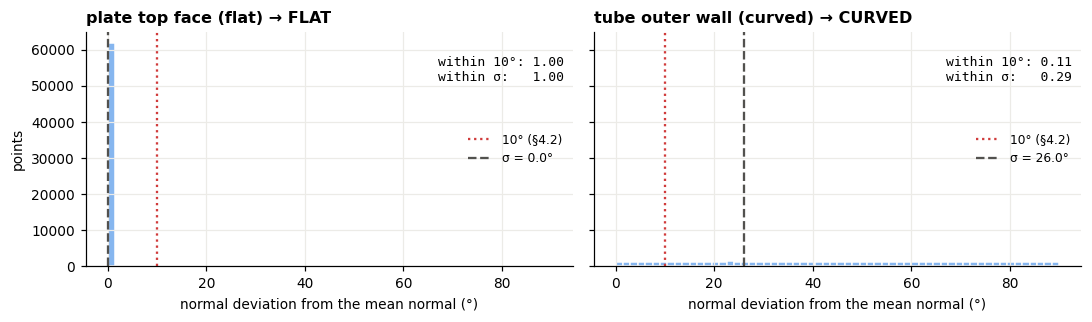

In [2]:
prep = prepare(SCENES["circle"][:1])[0]
c = prep.cloud("full_exterior", 0.0); _, lab = prep.oracle("surfaces", "full_exterior", 0.0)
faces = {f["face_id"]: f["ref"] for f in prep.scene["faces"]}
plate = c["xyz"][lab == next(k for k, v in faces.items() if v == "A:+w")]
tube = c["xyz"][lab == next(k for k, v in faces.items() if v == "B:lateral+")]
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, (name, P) in zip(axes, (("plate top face (flat)", plate), ("tube outer wall (curved)", tube))):
    n, _ = local_pca(P, k=20); dev = normal_deviation_deg(n); v = surface_kind(n)
    ax.hist(dev, bins=60, range=(0, 90), color="#86b6ef", edgecolor="white")
    ax.axvline(10, color="#d03b3b", linestyle=":", label="10° (§4.2)"); ax.axvline(v["sigma_deg"], color=INK2, linestyle="--", label=f"σ = {v['sigma_deg']:.1f}°")
    ax.set_title(f"{name} → {v['kind'].upper()}", loc="left"); ax.set_xlabel("normal deviation from the mean normal (°)")
    ax.text(0.98, 0.9, f"within 10°: {v['within_angle']:.2f}\nwithin σ:   {v['within_sigma']:.2f}", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, family="monospace")
    ax.legend(fontsize=8, loc="center right")
axes[0].set_ylabel("points")
plt.tight_layout(); plt.show()

**Reading it.** The angle rule separates the two surfaces cleanly (plate ≈ 1,0 within
10°, tube ≈ 0,1). The literal σ statistic does not: on this *exact* face σ is 0° and the
share "within σ" is degenerate (1,00 by convention), and on any face with measurement
noise it collapses — 0,19 for a plane with 0,05 mm jitter (`tests/test_lit_quadric.py`)
— which would call the flat blade curved. That is the reason it cannot be the rule the
authors ran, and it is question 1 for them.

One detail that the paper's order of operations settles: the normals are computed **per
welding surface, after segmentation**. A neighbourhood drawn from the whole cloud crosses
the crease at the seam and tilts the normals of every point within *k* neighbours of it;
on a small visible face that is more than 10 % of the points, and the face is voted
curved. Computing the PCA on the segmented surface — §3.1 as written — removes it.

## The fits — plane by total least squares, quadric by homogeneous least squares

Eq. 8–11 minimise Σ(ax+by+cz+d)² over (a, b, c, d) with no constraint, whose minimiser is
the zero vector; the estimator their ref. 21 describes (Shakarji & Srinivasan) is total
least squares with ‖n‖ = 1, which is what `fit_plane` does. Eq. 12 is the algebraic quadric
fit; `fit_quadric` solves it as the smallest right singular vector of the monomial design
matrix on centred, scaled coordinates. On a real tube wall the recovered coefficients say
"cylinder" without being told.

In [3]:
sp = fit_plane(plate); sq = fit_quadric(tube)
print(f"plate: TLS plane, rms residual {sp.rms_residual_mm:.4f} mm, normal {np.round(sp.normal, 3)}")
names = ("x²", "y²", "z²", "xy", "xz", "yz", "x", "y", "z", "1")
coef = sq.coef / np.abs(sq.coef[:3]).max()
print("tube: quadric, rms residual %.4f mm; coefficients (scaled coords, normalised):" % sq.rms_residual_mm)
print("   " + "  ".join(f"{n}:{v:+.2f}" for n, v in zip(names, coef)))
print("   -> two equal quadratic terms and a vanishing third: a cylinder along the third axis")

plate: TLS plane, rms residual 0.0000 mm, normal [0. 0. 1.]
tube: quadric, rms residual 0.0000 mm; coefficients (scaled coords, normalised):
   x²:-1.00  y²:-1.00  z²:-0.00  xy:+0.00  xz:-0.00  yz:-0.00  x:+0.00  y:-0.00  z:-0.00  1:+0.37
   -> two equal quadratic terms and a vanishing third: a cylinder along the third axis


## The seam — three intersection types, exact on exact geometry

The paper's seam is the intersection of the two fitted surfaces, with "the point clouds
within the threshold" of it as the actual weld positions. Implemented as: points of either
surface within `seam_tol` of the *other's* fit (reading 4) and whose projection lands
within `seam_tol` of the other's *points* (the fit is infinite, the patch is not), then
projected onto the intersection by alternating orthogonal projections. On synthetic exact
geometry the three configurations the curved families need all come back exact.

In [4]:
def grid(L=100.0, n=60):
    a = np.linspace(0.0, L, n); return np.stack(np.meshgrid(a, a), -1).reshape(-1, 2)
th = np.linspace(0, 2 * np.pi, 240, endpoint=False); g = grid()
A = np.column_stack([g[:, 0], g[:, 1] - 50, np.zeros(len(g))]); B = np.column_stack([g[:, 0], np.zeros(len(g)), g[:, 1]])
P = np.array([[30 * np.cos(t), 30 * np.sin(t), z] for z in np.linspace(0, 60, 40) for t in th])
base = np.column_stack([g[:, 0] - 50, g[:, 1] - 50, np.zeros(len(g))]); base = base[np.hypot(base[:, 0], base[:, 1]) > 31]
big = np.array([[x, 40 * np.cos(t), 40 * np.sin(t)] for x in np.linspace(-80, 80, 80) for t in th])
small = np.array([[20 * np.cos(t), 20 * np.sin(t), z] for z in np.linspace(35, 110, 50) for t in th]); small = small[np.hypot(small[:, 1], small[:, 2]) > 40.5]
cases = {"plane ∩ plane (T fold)": (np.vstack([A, B]), np.r_[np.zeros(len(A), int), np.ones(len(B), int)], lambda s: max(np.abs(s[:, 1]).max(), np.abs(s[:, 2]).max())),
         "plane ∩ cylinder (pipe on plate)": (np.vstack([base, P]), np.r_[np.zeros(len(base), int), np.ones(len(P), int)], lambda s: max(np.abs(np.hypot(s[:, 0], s[:, 1]) - 30).max(), np.abs(s[:, 2]).max())),
         "cylinder ∩ cylinder (saddle)": (np.vstack([big, small]), np.r_[np.zeros(len(big), int), np.ones(len(small), int)], lambda s: max(np.abs(np.hypot(s[:, 0], s[:, 1]) - 20).max(), np.abs(np.hypot(s[:, 1], s[:, 2]) - 40).max()))}
rows = []
for name, (pts, lab, err) in cases.items():
    r = detect(pts, region_labels=lab, part_labels=lab, voxel_mm=None, ordering="chain")
    rows.append(dict(case=name, seams=r.n_seams, kinds=" / ".join(s["kind"] for s in r.surfaces), points=len(r.seams[0]), max_err_mm=err(r.seams[0])))
print(pd.DataFrame(rows).to_string(index=False))

                            case  seams           kinds  points   max_err_mm
          plane ∩ plane (T fold)      1     flat / flat     180 0.000000e+00
plane ∩ cylinder (pipe on plate)      1   flat / curved     120 1.776357e-14
    cylinder ∩ cylinder (saddle)      1 curved / curved     306 9.403526e-08


## The ordering — the published distance sort folds a ring

§3.3 finds the initial point by a nearest-neighbour graph walk (eq. 13), then *"the
distances between all weld seam points and the initial point are calculated, and sorted in
order from small to large by bubble sort"*. Sorting by Euclidean distance from one end is
an arclength ordering on a straight seam and on the gently curved blade root of their
impeller. On a closed ring it interleaves the two sides at equal distance and the path
zig-zags across the pipe. Implemented as published (`ordering="distance"`), with a
nearest-neighbour chain from the same initial point as the corrected arm (`"chain"`), and
the delta is measured, never silently applied.

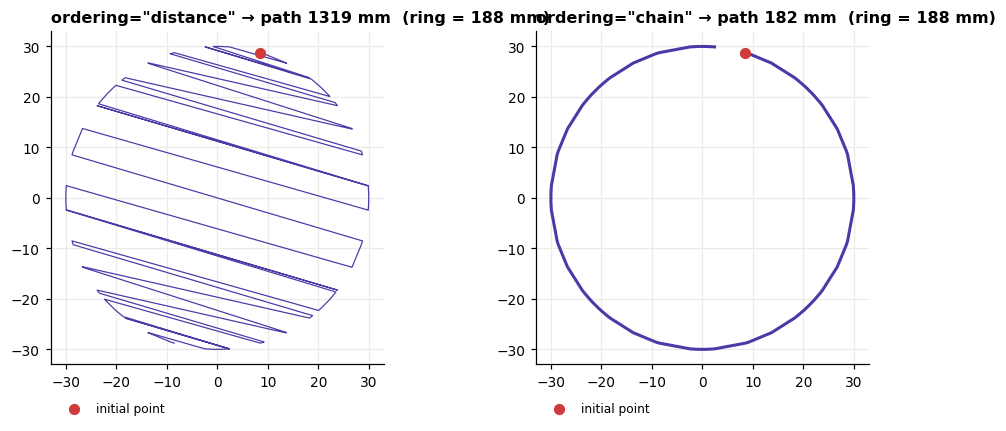

In [5]:
ring = detect(np.vstack([base, P]), region_labels=np.r_[np.zeros(len(base), int), np.ones(len(P), int)],
              part_labels=np.r_[np.zeros(len(base), int), np.ones(len(P), int)], voxel_mm=None, ordering="chain").seams[0]
L = lambda p: float(np.linalg.norm(np.diff(p, axis=0), axis=1).sum())
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, ordr in zip(axes, ("distance", "chain")):
    o = order_points(ring, ordr, seed=0)
    ax.plot(o[:, 0], o[:, 1], color=COLOR["lit-quadric"], linewidth=0.8 if ordr == "distance" else 2)
    ax.scatter(o[0, 0], o[0, 1], color="#d03b3b", s=40, zorder=3, label="initial point")
    ax.set_aspect("equal"); ax.set_title(f'ordering="{ordr}" → path {L(o):.0f} mm  (ring = {2 * np.pi * 30:.0f} mm)', loc="left")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.0, -0.08), ncol=1)
plt.tight_layout(); plt.show()

## The finite patch, and the far-side mirror the full view pays

A fitted plane is infinite. Without a patch test, a standing plate's side plane extended
downward meets the base plate's far side face, and the *extended* plane of every face clips
the corners of every other — on a plate T joint that is 15 "seams" from 55 face pairs. With
the projected-patch test the census on the same scene is two true fillets plus their two
**far-side mirrors**: the side plane of B really does intersect the *bottom* face of A, and
nothing in the mechanism knows that a seam is on the outside. That mirror is a property of
the full-exterior condition (both faces of A are in the cloud); the paper's own condition
is one camera, and in the single view the census is one fillet, cleanly.

In [6]:
prep = prepare(SCENES["line"][:1])[0]
faces = {f["face_id"]: f["ref"] for f in prep.scene["faces"]}
print("truth:", [(s["seam_class"], s["face_pair"], round(s["length_mm"])) for s in prep.scene["seams"] if s["weldable"] and s["matches_joint_type"]])
for view in ("full_exterior", "single"):
    c = prep.cloud(view, 0.0); _, lab = prep.oracle("surfaces", view, 0.0)
    r = detect(c["xyz"], region_labels=lab, part_labels=c["object_id"])
    census = {}
    for p in r.pairs: census[p["status"]] = census.get(p["status"], 0) + 1
    print(f"{view:14s} census {census}")
    for p, cl, sm in zip([p for p in r.pairs if p["status"] == "seam"], r.clusters, r.seams):
        print(f"   seam {faces[p['i']]} × {faces[p['j']]}  band {len(cl):4d}  extent {np.ptp(sm, axis=0).max():.0f} mm")

truth: [('fillet', ['A:+w', 'B:+w'], 116), ('fillet', ['A:+w', 'B:-w'], 116)]


full_exterior  census {'same_part': 25, 'no_band': 18, 'too_few': 2, 'too_short': 4, 'seam': 4, 'tangent': 2}
   seam A:+w × B:+w  band  180  extent 114 mm
   seam A:+w × B:-w  band  194  extent 112 mm
   seam A:-w × B:+w  band  192  extent 114 mm
   seam A:-w × B:-w  band  180  extent 115 mm


single         census {'same_part': 1, 'no_band': 1, 'seam': 1}
   seam A:+w × B:-w  band  222  extent 113 mm


## The families, through the harness — three arms, two views

Two scenes per T family plus a square butt, a corner and a lap. `L0` = the surfaces
oracle with part membership; `L1` = surfaces grown by region growing, every adjacent pair a
candidate. `distance` is the ordering as published, `chain` the corrected arm (at L0).
`lit-ransac`'s and `lit-lobb`'s Phase 4 medians on the same strata are the reference points.

In [7]:
rows = []
t0 = time.time()
for fam, dirs in SCENES.items():
    prep = prepare(dirs)
    for view in ("full_exterior", "single"):
        for arm, ordr in (("L0 distance", "distance"), ("L0 chain", "chain"), ("L1 chain", "chain")):
            df = run_matrix(prep, methods=["lit-quadric"], seeds=[0], verify_seeds=1, oracle=arm.startswith("L0"), view=view,
                            method_kw={"lit-quadric": {"ordering": ordr}})
            for _, r in df.iterrows():
                rows.append(dict(family=fam, view=view, arm=arm, f1=r.f1, precision=r.precision, recall=r.recall, rmse=r.rmse_med, n_pred=r.n_pred_seams, n_curved=r.n_curved))
Q = pd.DataFrame(rows); print(f"{len(Q)} rows in {time.time() - t0:.0f}s")
tbl = Q.groupby(["view", "arm", "family"]).f1.median().unstack("family")[list(SCENES)]
print(tbl.round(2).to_string())

120 rows in 629s
family                     line  circle  ellipse  saddle  rounded_rect  swept_path  arc_butt  butt  corner   lap
view          arm                                                                                               
full_exterior L0 chain     0.50    0.87     1.00    0.83          0.74        0.98      0.76  0.50     1.0  0.80
              L0 distance  0.50    0.40     0.48    0.40          0.28        0.98      0.77  0.50     1.0  0.80
              L1 chain     0.74    0.41     0.50    0.00          0.23        0.36      0.00  0.00     0.5  0.07
single        L0 chain     0.50    0.56     0.32    0.44          0.38        0.64      0.78  0.33     1.0  0.60
              L0 distance  0.50    0.56     0.32    0.44          0.38        0.64      0.78  0.33     1.0  0.60
              L1 chain     0.00    0.07     0.07    0.00          0.17        0.35      0.41  0.00     0.0  0.00


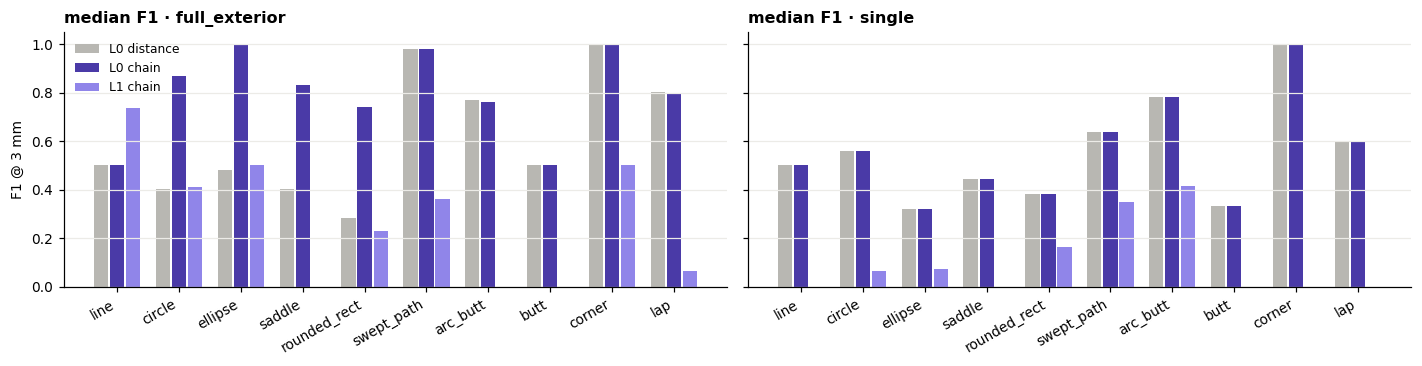

In [8]:
fams = list(SCENES); x = np.arange(len(fams)); w = 0.26
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True)
for ax, view in zip(axes, ("full_exterior", "single")):
    for k, (arm, col) in enumerate((("L0 distance", GRAY), ("L0 chain", COLOR["lit-quadric"]), ("L1 chain", "#9085e9"))):
        vals = [Q[(Q.view == view) & (Q.arm == arm) & (Q.family == f)].f1.median() for f in fams]
        ax.bar(x + (k - 1) * w, vals, width=w - 0.03, color=col, label=arm)
    ax.set_xticks(x); ax.set_xticklabels(fams, rotation=30, ha="right"); ax.set_title(f"median F1 · {view}", loc="left"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("F1 @ 3 mm"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** The mechanism does what the surface model says it should: the quadric
families (circle, ellipse, saddle) are recovered where every plane-pair method scores
zero, and the non-quadric families (rounded rectangle, swept B-spline) and the coplanar
butt are refused, with the pair census naming the reason. The three arms separate three
prices: the published *ordering* (distance vs chain — the rings), the *far-side mirror*
(full vs single — precision), and the *segmentation stage* (L0 vs L1 — the regions grown
by Alg. 1 on thin plates merge through the thickness, so surfaces and their pairs are
found by a different partition than the faces). One more price the table shows in the
`line` column: a straight T scored 0 when its **root gap (3,1 mm) exceeded the seam
threshold (2,25 mm)** — no point of either plate is then within the threshold of the
other plate's patch, and the joint is invisible to the mechanism. The authors' blade sits
in contact with the hub; on an ISO 5817 no. 617 gap range this is a gap-conditioned
coverage, and the batch stratifies it.

## One scene in 3D — a pipe on a plate

Grey cloud, green truth ring, the method's seam in violet, the two fitted surfaces' band
points in orange. Knobs: `FAM`, `VIEW`, `ELEV`, `AZIM`.

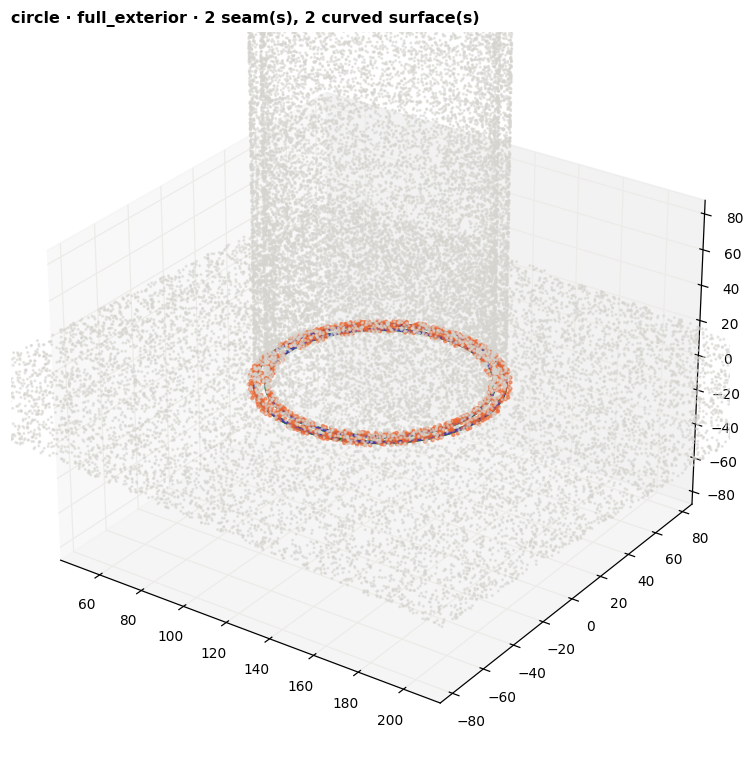

In [9]:
FAM, VIEW, ELEV, AZIM = "circle", "full_exterior", 28, -55
prep = prepare(SCENES[FAM][:1])[0]
c = prep.cloud(VIEW, 0.0); _, lab = prep.oracle("surfaces", VIEW, 0.0)
r = detect(c["xyz"], region_labels=lab, part_labels=c["object_id"], ordering="chain")
fig = plt.figure(figsize=(9, 7)); ax = fig.add_subplot(111, projection="3d")
step = max(1, len(c["xyz"]) // 25000)
ax.scatter(*c["xyz"][::step].T, s=1, color="#d5d4cf", alpha=0.5)
for g in prep.gt: ax.plot(*np.asarray(g).T, color="#008300", linewidth=2.5)
for cl in r.clusters: ax.scatter(*cl.T, s=4, color="#eb6834", alpha=0.6)
for s in r.seams: ax.plot(*s.T, color=COLOR["lit-quadric"], linewidth=2)
ctr = np.vstack(prep.gt).mean(axis=0); span = 0.5 * np.ptp(np.vstack(prep.gt), axis=0).max() + 40
ax.set_xlim(ctr[0] - span, ctr[0] + span); ax.set_ylim(ctr[1] - span, ctr[1] + span); ax.set_zlim(ctr[2] - span, ctr[2] + span)
ax.view_init(ELEV, AZIM); ax.set_title(f"{FAM} · {VIEW} · {r.n_seams} seam(s), {sum(s['kind'] == 'curved' for s in r.surfaces)} curved surface(s)", loc="left")
plt.tight_layout(); plt.show()

## Against the paper's own metric

Their Fig. 6 reports < 1 mm position error per axis against a taught path (whose own error
budget they do not state), on one flat and one curved blade. The comparable figure here is
the matched-path RMSE against constructed truth on the families the mechanism covers, with
the corrected ordering — a correct reimplementation against exact truth on a clean cloud
should come in **below** their number.

In [10]:
rows = []
for fam in ("line", "circle", "ellipse", "saddle"):
    for p_ in prepare(SCENES[fam]):
        pred, _ = REGISTRY["lit-quadric"].run(p_, 0, True, "full_exterior", 0.0, ordering="chain")
        for e in matched_path_errors(pred, p_.gt):
            if e["matched"]: rows.append(dict(family=fam, rmse=e["rmse"], me=e["me"], lateral=e["lateral_rmse"]))
R = pd.DataFrame(rows)
print(R.groupby("family").agg(seams=("rmse", "size"), rmse_med=("rmse", "median"), rmse_max=("rmse", "max"), me_max=("me", "max")).round(3).to_string())
print("\npaper: < 1 mm per axis (Fig. 6)")

         seams  rmse_med  rmse_max  me_max
family                                    
circle       3     0.008     0.014   0.096
ellipse      4     0.011     0.023   0.148
line         2     0.180     0.200   1.972
saddle       2     0.011     0.013   0.048

paper: < 1 mm per axis (Fig. 6)


## Determinism, verified

The graph walk starts "at a random point"; it is seeded, and on an open seam the walk's
terminal point is one of the two ends regardless of where it started. The registry carries
`randomised=False`, so the harness measures the spread over `verify_seeds` and it must be
exactly zero.

In [11]:
det = run_matrix(prepare(SCENES["line"] + SCENES["circle"]), methods=["lit-quadric"], seeds=range(4), verify_seeds=3, method_kw={"lit-quadric": {"ordering": "chain"}})
sp = spread(det); print(sp.round(3).to_string()); assert (sp.spread == 0).all(); print("\nzero spread - deterministic per seed")

        method             scene_id    min  median    max  std  count  spread
0  lit-quadric  9a8eb697-0002000000  1.000   1.000  1.000  0.0      3     0.0
1  lit-quadric  9a8eb697-0002000006  0.000   0.000  0.000  0.0      3     0.0
2  lit-quadric  bcd0f7cb-0002000001  1.000   1.000  1.000  0.0      3     0.0
3  lit-quadric  bcd0f7cb-0002000007  0.734   0.734  0.734  0.0      3     0.0

zero spread - deterministic per seed


## Open questions — and what to ask the authors

1. **The flat/curved statistic** (§3.1 vs §4.2): is the operational rule "≥ 90 % of the
   normals within 10° of the mean normal", and how is the mean normal defined?
2. **The plane fit** (eq. 8–11): with no norm constraint the printed system has the trivial
   solution; is the implemented estimator total least squares (their ref. 21)?
3. **Conditioning of the quadric fit** (eq. 12): are the coordinates centred/scaled, and how
   is the trivial solution excluded?
4. **The seam threshold** (§3.3): the value, and whether "the intersection line" is the
   analytic curve or the points near both surfaces.
5. **The ordering** (§3.3): sorting by distance from the initial point folds a closed ring;
   is the method meant for open seams only?
6. **Segmentation**: which region-growing criteria and thresholds split hub from blade, and
   is the cloud from a single camera pose (so each part shows one welding surface)?
7. **The metric** of Fig. 6: the error budget of the taught path, and whether the errors are
   per-axis means or maxima.